
## Dataset Preparation

1. **Load datasets**: Import the 2017 and 2018 CSV files.  
2. **Standardize columns**: Remove spaces and rename columns in the 2018 dataset to match 2017.  
3. **Merge datasets**: Concatenate both DataFrames into one.  
4. **Clean data**: Drop empty columns and verify the final shape.  
5. **Preview**: Check the first few rows to ensure correctness.


In [1]:
import pandas as pd

# Load datasets
df1 = pd.read_csv("Child-Data2017.csv")
df2 = pd.read_csv("Child-Data2018.csv")

# Strip whitespace from df2 column names
df2.columns = df2.columns.str.strip()

# Rename columns in df2 that match df1
df2_clean = df2.rename(columns={
    "A1": "A1_Score",
    "A2": "A2_Score",
    "A3": "A3_Score",
    "A4": "A4_Score",
    "A5": "A5_Score",
    "A6": "A6_Score",
    "A7": "A7_Score",
    "A8": "A8_Score",
    "A9": "A9_Score",
    "A10": "A10_Score",
    "Age": "age",
    "Sex": "gender",
    "Ethnicity": "ethnicity",
    "Jaundice": "jundice",
    "Family_ASD": "austim",
    "Residence": "contry_of_res",
    "Used_App_Before": "used_app_before",
    "Score": "result",
    "Screening Type": "age_desc",
    "User": "relation",
    "Class": "Class/ASD"
})




# Concatenate both datasets keeping all columns
df_final = pd.concat([df1, df2_clean], ignore_index=True, sort=False)
# Check the final shape
df_final.rename(columns={"austim": "Family_ASD"}, inplace=True)

print(f"Number of rows: {df_final.shape[0]}")  # Should be 801
print(f"Number of columns: {df_final.shape[1]}")
df_final.head()

# Save the cleaned DataFrame to a CSV file



df_final.info()
df_final.head()


Number of rows: 801
Number of columns: 25
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       292 non-null    float64
 1   A1_Score                 801 non-null    int64  
 2   A2_Score                 801 non-null    int64  
 3   A3_Score                 801 non-null    int64  
 4   A4_Score                 801 non-null    int64  
 5   A5_Score                 801 non-null    int64  
 6   A6_Score                 801 non-null    int64  
 7   A7_Score                 801 non-null    int64  
 8   A8_Score                 801 non-null    int64  
 9   A9_Score                 801 non-null    int64  
 10  A10_Score                801 non-null    int64  
 11  age                      801 non-null    object 
 12  gender                   801 non-null    object 
 13  ethnicity                801 non-null 

,id,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,Family_ASD,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD,Case No,Why taken the screening,Language
0,1.0,1,1,0,0,1,1,0,1,0,...,no,Jordan,no,5,4-11 years,Parent,NaN,NaN,NaN,NaN
1,2.0,1,1,0,0,1,1,0,1,0,...,no,Jordan,no,5,4-11 years,Parent,NO,NaN,NaN,NaN
2,3.0,1,1,0,0,0,1,1,1,0,...,no,Jordan,yes,5,4-11 years,?,NaN,NaN,NaN,NaN
3,4.0,0,1,0,0,1,1,0,0,0,...,no,Jordan,no,4,4-11 years,?,NaN,NaN,NaN,NaN
4,5.0,1,1,1,1,1,1,1,1,1,...,no,United States,no,10,4-11 years,Parent,NaN,NaN,NaN,NaN


# Dropping Unnecessary Columns from the Dataset

1. **Remove Irrelevant Features**: Certain columns that are not needed for analysis or modeling (e.g., demographic info, administrative details) are dropped to simplify the dataset.  
2. **Handle Missing Columns**: The `errors='ignore'` parameter ensures that if some columns are not present, the code will not raise an error.  
3. **Inspect Data**: Use `.head()` to quickly preview the updated dataset and verify that the unnecessary columns were removed.  
4.  `.info()` can be used to check the remaining columns and data types.


In [2]:
df_final = df_final.drop(
    ["id","ethnicity", "contry_of_res", "used_app_before", "result", "age_desc", "relation" ,"Case No" ,"Why taken the screening" ,"Language"],
    axis=1,
    errors='ignore'
)
df_final = df_final[df_final["age"] != "?"]
df_final.head()
# df_final.info()
# print(list(df_final.columns))

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,jundice,Family_ASD,Class/ASD
0,1,1,0,0,1,1,0,1,0,0,6,m,no,no,NaN
1,1,1,0,0,1,1,0,1,0,0,6,m,no,no,NO
2,1,1,0,0,0,1,1,1,0,0,6,m,no,no,NaN
3,0,1,0,0,1,1,0,0,0,1,5,f,yes,no,NaN
4,1,1,1,1,1,1,1,1,1,1,5,m,yes,no,NaN


Class/ASD
Unknow    636
YES        85
NO         76
Name: count, dtype: int64


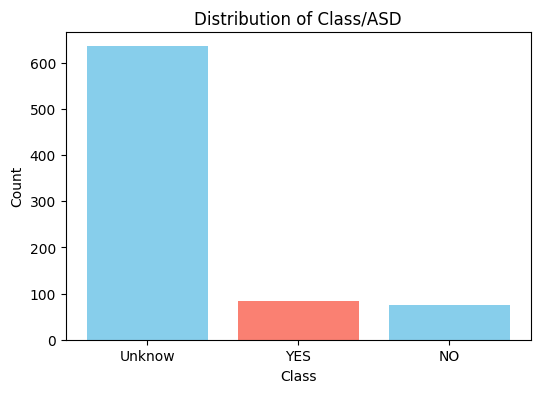

In [3]:
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns


df_final['Class/ASD'] = df_final['Class/ASD'].fillna("Unknow").astype(str)
class_counts = df_final ['Class/ASD'].value_counts(dropna=False)  # dropna=False to see unlabeled too
print(class_counts)

# Plot using Matplotlib
plt.figure(figsize=(6,4))
plt.bar(class_counts.index, class_counts.values, color=['skyblue','salmon'])
plt.title("Distribution of Class/ASD")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()
df_final.to_csv("Autism.csv", index=False)

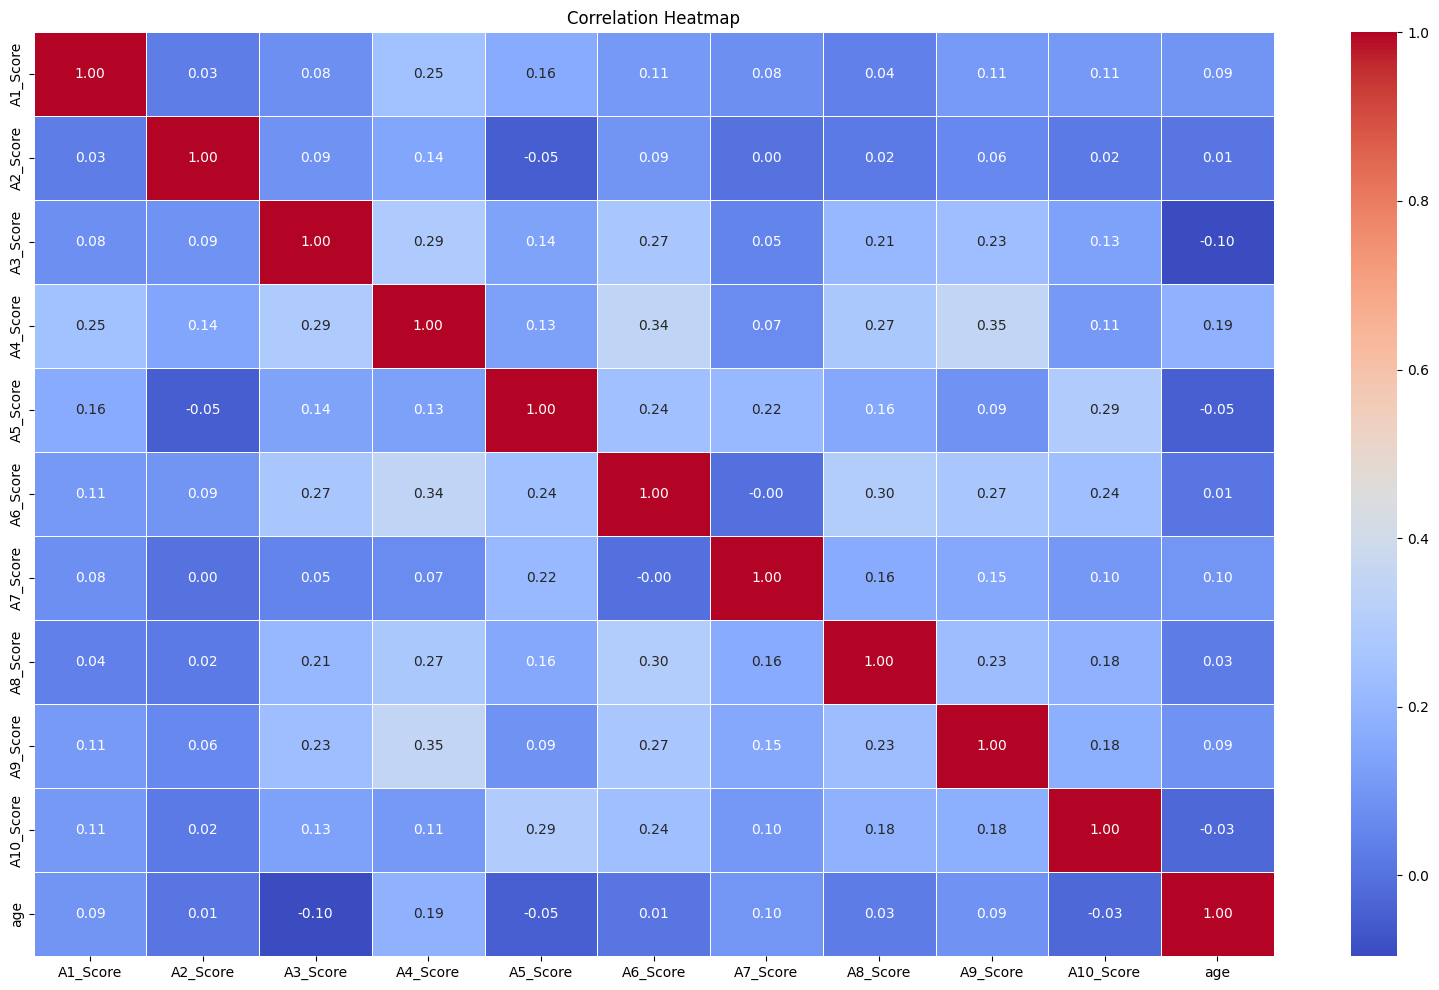

In [4]:
df_corr = df_final.drop(["jundice" ,"gender" ,"Family_ASD" ,"Class/ASD"] , axis =1) 
matrix =df_corr.corr()

plt.figure(figsize=(20,12))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [5]:
from sklearn.preprocessing import MinMaxScaler

categorical_cols = ['gender', 'jundice', 'Family_ASD']
target_col = 'Class/ASD'

# 1) Dummy encoding directly in df_final
df_final = pd.get_dummies(df_final, columns=categorical_cols, drop_first=True)

# 2) Scale age inside df_final
scaler = MinMaxScaler()
df_final['age'] = scaler.fit_transform(df_final[['age']])
# Convert labels to numeric



df_final

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,Class/ASD,gender_m,jundice_yes,Family_ASD_yes
0,1,1,0,0,1,1,0,1,0,0,0.285714,Unknow,True,False,False
1,1,1,0,0,1,1,0,1,0,0,0.285714,NO,True,False,False
2,1,1,0,0,0,1,1,1,0,0,0.285714,Unknow,True,False,False
3,0,1,0,0,1,1,0,0,0,1,0.142857,Unknow,False,True,False
4,1,1,1,1,1,1,1,1,1,1,0.142857,Unknow,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,1,1,1,1,1,1,1,0,1,1,0.714286,Unknow,True,False,False
797,1,0,1,0,1,1,1,1,0,1,0.714286,YES,True,False,False
798,1,1,1,1,0,1,0,0,1,1,0.142857,Unknow,True,False,True
799,1,1,1,0,0,1,0,1,1,1,0.000000,Unknow,False,False,False


In [6]:
df_final['Class/ASD'] = df_final['Class/ASD'].map({
    'YES': 1,
    'NO': 0,
    'Unknow': -1
})

In [7]:
from sklearn.model_selection import train_test_split
# Labeled samples
df_labeled = df_final[df_final['Class/ASD'] != -1]

# Unlabeled samples
df_unlabeled = df_final[df_final['Class/ASD'] == -1]

y = df_labeled[target_col]
X = df_labeled.drop(target_col, axis=1)
X_train, X_test, y_train, y_test = train_test_split(X,y ,random_state=104,train_size=0.8, shuffle=True)
  
df_labeled 

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,Class/ASD,gender_m,jundice_yes,Family_ASD_yes
1,1,1,0,0,1,1,0,1,0,0,0.285714,0,True,False,False
7,1,1,1,1,1,1,1,1,0,0,0.142857,1,False,False,False
8,1,1,1,1,1,1,1,0,0,0,1.000000,1,False,False,False
13,1,0,0,0,0,0,1,0,0,0,0.000000,0,False,False,False
20,1,1,1,1,1,1,1,0,1,0,0.142857,1,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
789,1,1,1,1,1,1,1,1,1,1,0.000000,1,True,True,False
790,1,0,0,0,1,1,0,0,0,1,0.000000,0,False,False,False
793,1,1,1,1,1,1,0,0,0,0,0.142857,0,False,True,False
797,1,0,1,0,1,1,1,1,0,1,0.714286,1,True,False,False


In [8]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()

gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)
y_prob = gnb.predict_proba(X_test)
y_pred_proba = gnb.predict_proba(X_test)[:, 1] 
print(y_pred[:5])  
print(y_pred_proba[:5])

from sklearn.metrics import classification_report, confusion_matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

class_names = y_train.unique()
class_report = classification_report(y_test, y_pred, target_names=[str(c) for c in class_names])
print("Classification Report:")
print(class_report)

[0 0 0 0 0]
[1.08186259e-03 1.15765994e-04 4.68243378e-01 1.94032192e-06
 1.51192969e-01]
Confusion Matrix:
[[17  2]
 [ 1 13]]
Classification Report:
              precision    recall  f1-score   support

           1       0.94      0.89      0.92        19
           0       0.87      0.93      0.90        14

    accuracy                           0.91        33
   macro avg       0.91      0.91      0.91        33
weighted avg       0.91      0.91      0.91        33



AUC Score: 0.9812


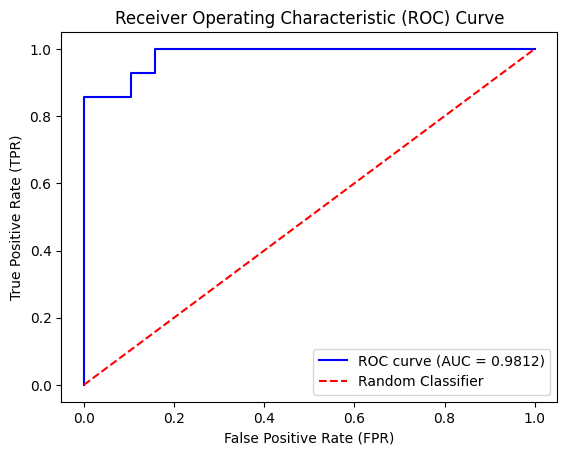

In [9]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Calculate the AUC Score
# y_pred_proba is the probability of the positive class (1)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC Score: {roc_auc:.4f}")

# 2. Calculate the ROC Curve data points (FPR, TPR, Thresholds)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# 3. Plot the ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

In [10]:
# 1. Calculate Youden's J statistic for all thresholds
J = tpr - fpr

# 2. Find the index of the maximum J value
# The 'argmax' function tells us *where* the maximum value is located
optimal_idx = J.argmax()

# 3. Retrieve the optimal FPR, TPR, and Threshold
optimal_fpr = fpr[optimal_idx]
optimal_tpr = tpr[optimal_idx]
optimal_threshold = thresholds[optimal_idx]

# 4. Print the results
print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"  --> Corresponding FPR: {optimal_fpr:.4f}")
print(f"  --> Corresponding TPR: {optimal_tpr:.4f}")

Optimal Threshold: 0.9205
  --> Corresponding FPR: 0.0000
  --> Corresponding TPR: 0.8571


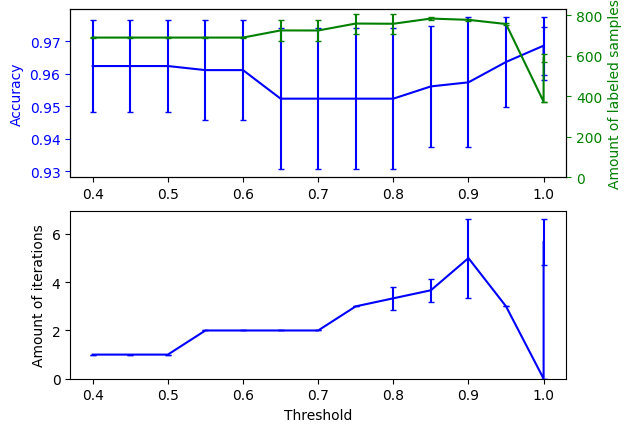

In [11]:
# from sklearn.naive_bayes import GaussianNB
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

y = df_final[target_col]
X = df_final.drop(target_col, axis=1)

n_splits = 3
thresholds = np.arange(0.4, 1.05, 0.05)
thresholds = np.append(thresholds, 0.99999)

scores = np.empty((len(thresholds), n_splits))
amount_labeled = np.empty((len(thresholds), n_splits))
amount_iterations = np.empty((len(thresholds), n_splits))
total_samples = y.shape[0]

base_classifier = GaussianNB()

for i, threshold in enumerate(thresholds):
    self_training_clf = SelfTrainingClassifier(base_classifier, threshold=threshold)
    skfolds = StratifiedKFold(n_splits=n_splits)

    for fold, (train_index, test_index) in enumerate(skfolds.split(X, y)):
        # Use .iloc for row selection with KFold naming convention
        X_train_KFold, X_test_KFold = X.iloc[train_index], X.iloc[test_index]
        y_train_KFold, y_test_KFold = y.iloc[train_index], y.iloc[test_index]
        
        # Create copy for true labels
        y_test_KFold_true = y_test_KFold.copy()
        y_test_KFold_true[y_test_KFold_true == -1] = 0  # Replace -1 in test for accuracy check

        # Fit self-training classifier
        self_training_clf.fit(X_train_KFold, y_train_KFold)

        # Count labeled samples at the end
        labeled_counts = np.unique(self_training_clf.labeled_iter_, return_counts=True)[1]
        amount_labeled[i, fold] = total_samples - labeled_counts[0]
        
        # Count iterations
        amount_iterations[i, fold] = np.max(self_training_clf.labeled_iter_)

        # Predict on test set
        y_pred_KFold = self_training_clf.predict(X_test_KFold)
        y_pred_KFold[y_test_KFold == -1] = 0
        scores[i, fold] = accuracy_score(y_test_KFold_true, y_pred_KFold)

# Plot results
ax1 = plt.subplot(211)
ax1.errorbar(thresholds, scores.mean(axis=1), yerr=scores.std(axis=1), capsize=2, color="b")
ax1.set_ylabel("Accuracy", color="b")
ax1.tick_params("y", colors="b")

ax2 = ax1.twinx()
ax2.errorbar(thresholds, amount_labeled.mean(axis=1), yerr=amount_labeled.std(axis=1), capsize=2, color="g")
ax2.set_ylim(bottom=0)
ax2.set_ylabel("Amount of labeled samples", color="g")
ax2.tick_params("y", colors="g")

ax3 = plt.subplot(212, sharex=ax1)
ax3.errorbar(thresholds, amount_iterations.mean(axis=1), yerr=amount_iterations.std(axis=1), capsize=2, color="b")
ax3.set_ylim(bottom=0)
ax3.set_ylabel("Amount of iterations")
ax3.set_xlabel("Threshold")

plt.show()

In [12]:
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.metrics import accuracy_score, classification_report , confusion_matrix

X_unlabeled = df_unlabeled.drop(target_col, axis=1) 

# Create the full training feature set (Labeled TRAIN + Unlabeled)
X_all = pd.concat([X_train, X_unlabeled], ignore_index=True)

# Create the corresponding label set (y_train + placeholders for unlabeled)
# The placeholder for unlabeled data MUST be -1 for the classifier to work
y_unlabeled_placeholder = np.full(X_unlabeled.shape[0], -1) 
y_all = pd.concat([y_train, pd.Series(y_unlabeled_placeholder)], ignore_index=True)


# --- 2. CONFIGURE AND TRAIN THE SELF-TRAINING MODEL ---

# Initialize your base model
base_estimator = GaussianNB()

# Initialize the SelfTrainingClassifier with your threshold (0.92)
self_training_model = SelfTrainingClassifier(
    estimator=base_estimator,
    threshold=0.90,  # Your high-confidence threshold
    criterion='threshold',
    max_iter=10
)

print("Starting Self-Training on X_train + X_unlabeled...")
# Fit the model on ALL available training data (labeled and unlabeled placeholder)
self_training_model.fit(X_all, y_all)
print("Self-Training complete.")


# --- 3. FINAL EVALUATION ON UNSEEN TEST DATA ---

# Make predictions on the completely unseen X_test
y_pred_final = self_training_model.predict(X_test)

# Calculate Accuracy and print the Classification Report
final_accuracy = accuracy_score(y_test, y_pred_final)

print("\n--- Final Model Performance on UNSEEN X_test ---")
print(f"Final Self-Trained Model Accuracy: {final_accuracy:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_final))
y_pred_final = self_training_model.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_final)

# Extract values
TN, FP, FN, TP = cm.ravel()  # Flatten 2x2 matrix into values

print("Confusion Matrix (raw numbers):")
print(cm)
print(f"True Positives (TP): {TP}")
print(f"True Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")

Starting Self-Training on X_train + X_unlabeled...
Self-Training complete.

--- Final Model Performance on UNSEEN X_test ---
Final Self-Trained Model Accuracy: 0.8485
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.84      0.86        19
           1       0.80      0.86      0.83        14

    accuracy                           0.85        33
   macro avg       0.84      0.85      0.85        33
weighted avg       0.85      0.85      0.85        33

Confusion Matrix (raw numbers):
[[16  3]
 [ 2 12]]
True Positives (TP): 12
True Negatives (TN): 16
False Positives (FP): 3
False Negatives (FN): 2


In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def predict_asd_probability(model, scaler, training_columns, 
                            A1_Score, A2_Score, A3_Score, A4_Score, A5_Score,
                            A6_Score, A7_Score, A8_Score, A9_Score, A10_Score,
                            age, gender, jundice, Family_ASD):
    """
    model: trained SelfTrainingClassifier
    scaler: fitted MinMaxScaler for numeric features
    training_columns: list of columns used during training (after one-hot encoding)
    Returns probability for each class (0 = No, 1 = Yes)
    """

    # Create input DataFrame
    input_df = pd.DataFrame([{
        'A1_Score': A1_Score, 'A2_Score': A2_Score, 'A3_Score': A3_Score,
        'A4_Score': A4_Score, 'A5_Score': A5_Score, 'A6_Score': A6_Score,
        'A7_Score': A7_Score, 'A8_Score': A8_Score, 'A9_Score': A9_Score,
        'A10_Score': A10_Score, 'age': age,
        'gender': gender, 'jundice': jundice, 'Family_ASD': Family_ASD
    }])

    # Scale numeric features
    numeric_cols = ['A1_Score','A2_Score','A3_Score','A4_Score','A5_Score',
                    'A6_Score','A7_Score','A8_Score','A9_Score','A10_Score','age']
    # Scale numeric features (only age)
    input_df["age"] = scaler.transform(input_df[["age"]])


    # One-hot encode categorical features
    input_df = pd.get_dummies(input_df)

    # Ensure all columns match training columns
    for col in training_columns:
        if col not in input_df.columns:
            input_df[col] = 0
    input_df = input_df[training_columns]

    # 5. Predict probabilities
    prob = model.predict_proba(input_df)[0]

    # 6. Determine predicted class
    predicted_class = 'No' if prob[0] > prob[1] else 'Yes'

    # 7. Return predicted class and probability details
    return      {
    'predicted_class': predicted_class,
    'probabilities': {
        'No (0)': round(prob[0], 3),   # round to 3 decimals
        'Yes (1)': round(prob[1], 3)
    }
     }

In [14]:
X_train_dummies = pd.get_dummies(X_train)  # if not already done
training_columns = list(X_train_dummies.columns)
result = predict_asd_probability(
    self_training_model, scaler, training_columns,
    A1_Score=1, A2_Score=1, A3_Score=0, A4_Score=0, A5_Score=1,
    A6_Score=1, A7_Score=0, A8_Score=1, A9_Score=0, A10_Score=1,
    age=6, gender='f', jundice='yes', Family_ASD='yes'
)
print (result)

{'predicted_class': 'No', 'probabilities': {'No (0)': 1.0, 'Yes (1)': 0.0}}


# The Label propbagation Method 

In [15]:
df_final.head()
X
y

0     -1
1      0
2     -1
3     -1
4     -1
      ..
796   -1
797    1
798   -1
799   -1
800    0
Name: Class/ASD, Length: 797, dtype: int64

## giving a weight for As_score

In [16]:
from sklearn.semi_supervised import LabelPropagation
from sklearn.metrics.pairwise import rbf_kernel

model = LabelPropagation(kernel='rbf', gamma=20, max_iter=1000)
model.fit(X_all, y_all)
y_pred_LabelPropagation = model.predict(X_test)

# Calculate Accuracy and print the Classification Report
final_accuracy = accuracy_score(y_test, y_pred_LabelPropagation )

print("\n--- Final Model Performance on UNSEEN X_test ---")
print(f"Final Self-Trained Model Accuracy: {final_accuracy:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_LabelPropagation ))

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_LabelPropagation )

# Extract values
TN, FP, FN, TP = cm.ravel()  # Flatten 2x2 matrix into values

print("Confusion Matrix (raw numbers):")
print(cm)
print(f"True Positives (TP): {TP}")
print(f"True Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")



--- Final Model Performance on UNSEEN X_test ---
Final Self-Trained Model Accuracy: 0.8182
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.68      0.81        19
           1       0.70      1.00      0.82        14

    accuracy                           0.82        33
   macro avg       0.85      0.84      0.82        33
weighted avg       0.87      0.82      0.82        33

Confusion Matrix (raw numbers):
[[13  6]
 [ 0 14]]
True Positives (TP): 14
True Negatives (TN): 13
False Positives (FP): 6
False Negatives (FN): 0


In [17]:
result = predict_asd_probability(
    model, scaler, training_columns,
    A1_Score=1, A2_Score=1, A3_Score=0, A4_Score=0, A5_Score=1,
    A6_Score=1, A7_Score=0, A8_Score=1, A9_Score=0, A10_Score=1,
    age=6, gender='f', jundice='yes', Family_ASD='yes'
)
print (result)

{'predicted_class': 'Yes', 'probabilities': {'No (0)': 0.0, 'Yes (1)': 1.0}}


In [18]:
from sklearn.semi_supervised import LabelSpreading
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train the model (same idea as LabelPropagation)
LabelSpreading_model = LabelSpreading(kernel='rbf', gamma=20, max_iter=1000)
LabelSpreading_model.fit(X_all, y_all)

# Predict on unseen test data
y_pred_LabelSpreading = LabelSpreading_model.predict(X_test)

# Accuracy
final_accuracy = accuracy_score(y_test, y_pred_LabelSpreading)

print("\n--- Final Model Performance on UNSEEN X_test ---")
print(f"Final Self-Trained Model Accuracy: {final_accuracy:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_LabelSpreading))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_LabelSpreading)
TN, FP, FN, TP = cm.ravel()

print("Confusion Matrix (raw numbers):")
print(cm)
print(f"True Positives (TP): {TP}")
print(f"True Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")



--- Final Model Performance on UNSEEN X_test ---
Final Self-Trained Model Accuracy: 0.8485
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.74      0.85        19
           1       0.74      1.00      0.85        14

    accuracy                           0.85        33
   macro avg       0.87      0.87      0.85        33
weighted avg       0.89      0.85      0.85        33

Confusion Matrix (raw numbers):
[[14  5]
 [ 0 14]]
True Positives (TP): 14
True Negatives (TN): 14
False Positives (FP): 5
False Negatives (FN): 0


In [19]:
result = predict_asd_probability(
    model, scaler, training_columns,
    A1_Score=1, A2_Score=1, A3_Score=0, A4_Score=0, A5_Score=1,
    A6_Score=1, A7_Score=0, A8_Score=1, A9_Score=0, A10_Score=1,
    age=6, gender='f', jundice='yes', Family_ASD='yes'
)
print (result)

{'predicted_class': 'Yes', 'probabilities': {'No (0)': 0.0, 'Yes (1)': 1.0}}
